# 01  Exploratory Data Analysis (EDA)

## Objective
Understand the real Daraz Nepal dataset before modelling.

## Input
- Raw scraped reviews: `data/raw/scraped_reviews/scraped_reviews.csv`

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import os

df = pd.read_csv('../data/raw/scraped_reviews/scraped_reviews.csv')
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nClass distribution:")
print(df['sentiment_label'].value_counts())

Shape: (4429, 6)

Columns: ['itemId', 'rating', 'review_text', 'review_date', 'source', 'sentiment_label']

Class distribution:
sentiment_label
positive    2019
neutral     1210
negative    1200
Name: count, dtype: int64


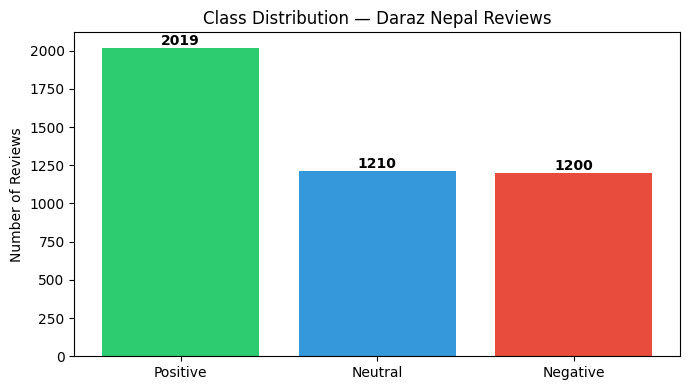

Saved class_distribution.png


In [6]:
# Chart 1 — Class distribution
labels = ['Positive', 'Neutral', 'Negative']
values = [2019, 1210, 1200]
colors = ['#2ECC71', '#3498DB', '#E74C3C']

plt.figure(figsize=(7, 4))
bars = plt.bar(labels, values, color=colors)
plt.title('Class Distribution — Daraz Nepal Reviews')
plt.ylabel('Number of Reviews')
for bar, val in zip(bars, values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
             str(val), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('../results/class_distribution.png', dpi=150)
plt.show()
print("Saved class_distribution.png")

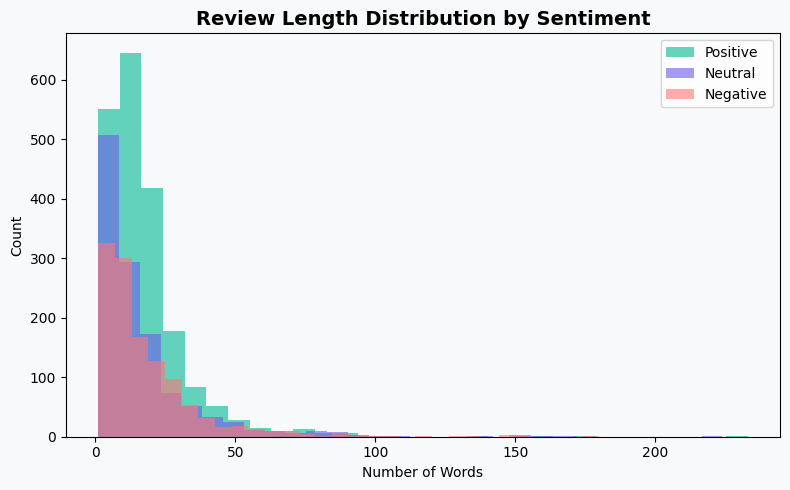

Saved review_length_distribution.png


In [7]:
# Chart 2 - Review length distribution
df['review_length'] = df['review_text'].str.split().str.len()

plt.figure(figsize=(8, 5))
ax = plt.axes()
ax.set_facecolor('#F8F9FA')
plt.gcf().set_facecolor('#F8F9FA')

for label, color in [('positive', '#00B894'), ('neutral', '#6C5CE7'), ('negative', '#FF7675')]:
    subset = df[df['sentiment_label'] == label]['review_length']
    plt.hist(subset, bins=30, alpha=0.6, label=label.capitalize(), color=color)

plt.title('Review Length Distribution by Sentiment', fontsize=14, fontweight='bold')
plt.xlabel('Number of Words')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.savefig('../results/review_length_distribution.png', dpi=150)
plt.show()
print("Saved review_length_distribution.png")

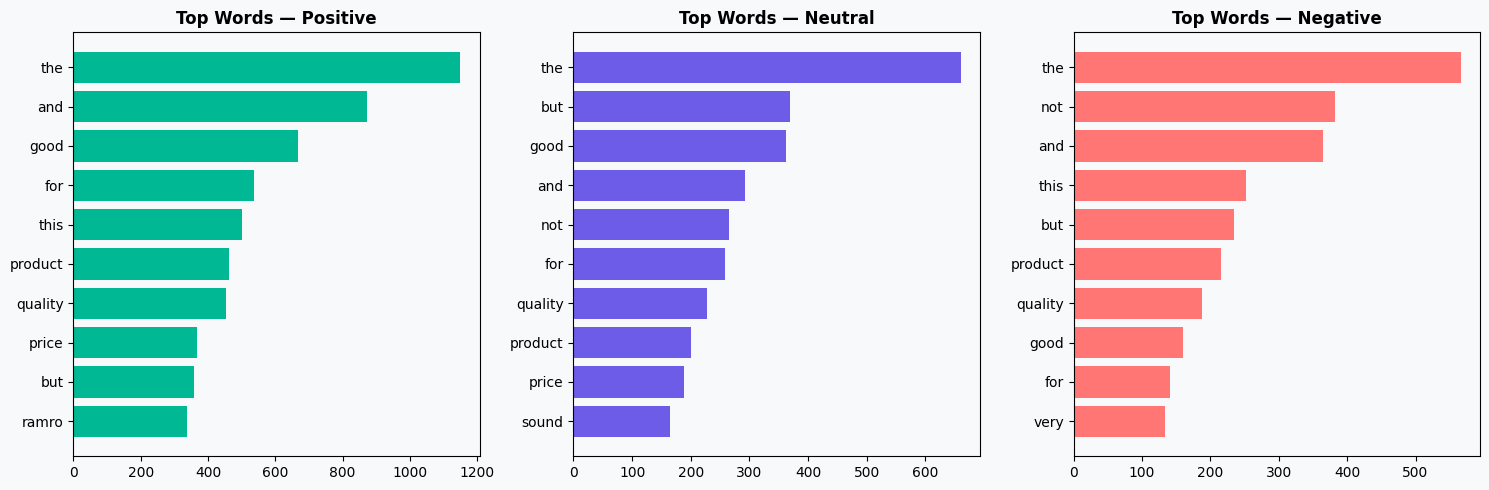

Saved top_words.png


In [8]:
from collections import Counter

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.patch.set_facecolor('#F8F9FA')

for ax, (label, color) in zip(axes, [('positive', '#00B894'), ('neutral', '#6C5CE7'), ('negative', '#FF7675')]):
    text = ' '.join(df[df['sentiment_label'] == label]['review_text'].dropna())
    words = [w.lower() for w in text.split() if len(w) > 2]
    top_words = Counter(words).most_common(10)
    words_list, counts = zip(*top_words)
    
    ax.barh(words_list[::-1], counts[::-1], color=color)
    ax.set_title(f'Top Words — {label.capitalize()}', fontweight='bold')
    ax.set_facecolor('#F8F9FA')

plt.tight_layout()
plt.savefig('../results/top_words.png', dpi=150)
plt.show()
print("Saved top_words.png")